<div style="
    text-align: center; 
    background: linear-gradient(135deg, #0062ff 0%, #00d4ff 100%); 
    font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; 
    color: white; 
    padding: 35px 20px; 
    border-radius: 15px; 
    box-shadow: 0 10px 25px rgba(0, 98, 255, 0.3);
    margin-bottom: 25px;">
    <div style="font-size: 35px; font-weight: 800; letter-spacing: 1.5px; text-transform: uppercase; line-height: 1.2;">
        Trực Quan Hóa Dữ Liệu - Lab 03
    </div>
    <div style="font-size: 16px; font-weight: 500; margin-top: 10px; font-style: italic; opacity: 0.9;">
        "Xây dựng mô hình dữ liệu và trực quan hóa bằng Power BI"
    </div>
    <div style="font-size: 18px; font-weight: 600; margin-top: 15px; border-top: 1px solid rgba(255,255,255,0.4); display: inline-block; padding-top: 10px; letter-spacing: 1px;">
        NHÓM 05 - FIT-HCMUS
    </div>
</div>

<div style="text-align: center; font-size: 40px; font-weight: bold;">
  KHÁM PHÁ DỮ LIỆU PHIM TMDB (EDA)
</div>

## 1. Giới thiệu EDA và dữ liệu đầu vào

Mục tiêu của bước EDA này là thực hiện khảo sát, đánh giá sơ bộ cấu trúc và phân bố của tập dữ liệu sạch sau bước tiền xử lý trước khi tiến hành trực quan hóa trên Power BI.

**Phạm vi dữ liệu:**
- Tập trung nghiên cứu phim thuộc các quốc gia: Việt Nam, Hàn Quốc, Trung Quốc.
- Khoảng thời gian: Năm phát hành từ 2000 đến 2025.
- Các file dữ liệu đầu vào gồm file sạch tổng hợp và 7 file đã được tách bảng quan hệ Dim/Fact/Bridge.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị dataframe và matplotlib
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_theme(style="whitegrid")

# Tự động điều chỉnh đường dẫn nếu chạy từ thư mục gốc hoặc thư mục 'notebooks'
if os.path.basename(os.getcwd()) == "notebooks":
    DATA_CLEAN_PATH = "../data/processed/tmdb_vn_kr_cn_2000_2025_scored.csv"
    POWERBI_DIR = "../data/processed/powerbi/"
else:
    DATA_CLEAN_PATH = "data/processed/tmdb_vn_kr_cn_2000_2025_scored.csv"
    POWERBI_DIR = "data/processed/powerbi/"

# Đường dẫn đến các bảng Dim/Fact/Bridge
DIM_PHIM_PATH = os.path.join(POWERBI_DIR, "DimPhim.csv")
FACT_HS_PATH = os.path.join(POWERBI_DIR, "FactHieuSuatPhim.csv")
DIM_TG_PATH = os.path.join(POWERBI_DIR, "DimThoiGian.csv")
DIM_QG_PATH = os.path.join(POWERBI_DIR, "DimQuocGia.csv")
BRIDGE_QG_PATH = os.path.join(POWERBI_DIR, "BridgePhimQuocGia.csv")
DIM_TL_PATH = os.path.join(POWERBI_DIR, "DimTheLoai.csv")
BRIDGE_TL_PATH = os.path.join(POWERBI_DIR, "BridgePhimTheLoai.csv")

print("Duong dan file du lieu sach tong hop:", DATA_CLEAN_PATH)
print("Duong dan thu muc Power BI:", POWERBI_DIR)

Duong dan file du lieu sach tong hop: ../data/processed/tmdb_vn_kr_cn_2000_2025_scored.csv
Duong dan thu muc Power BI: ../data/processed/powerbi/


## 2. Đọc dữ liệu và kiểm tra cấu trúc các bảng

Đọc tất cả các bảng dữ liệu sau tiền xử lý, kiểm tra kích thước các bảng, hiển thị một số dòng dữ liệu mẫu và kiểm tra kiểu dữ liệu của các cột.

In [2]:
# Doc cac bang du lieu
df_clean = pd.read_csv(DATA_CLEAN_PATH)
dim_phim = pd.read_csv(DIM_PHIM_PATH)
fact_hs = pd.read_csv(FACT_HS_PATH)
dim_tg = pd.read_csv(DIM_TG_PATH)
dim_qg = pd.read_csv(DIM_QG_PATH)
bridge_qg = pd.read_csv(BRIDGE_QG_PATH)
dim_tl = pd.read_csv(DIM_TL_PATH)
bridge_tl = pd.read_csv(BRIDGE_TL_PATH)

# In kich thuoc cac bang
print("Kich thuoc cac bang du lieu:")
print(f"  - df_clean:          {df_clean.shape}")
print(f"  - dim_phim:          {dim_phim.shape}")
print(f"  - fact_hs:           {fact_hs.shape}")
print(f"  - dim_tg:            {dim_tg.shape}")
print(f"  - dim_qg:            {dim_qg.shape}")
print(f"  - bridge_qg:         {bridge_qg.shape}")
print(f"  - dim_tl:            {dim_tl.shape}")
print(f"  - bridge_tl:         {bridge_tl.shape}")

# Hien thi thong tin bang Fact va Dim chinh
print("\nThong tin bang FactHieuSuatPhim:")
print(fact_hs.info())
display(fact_hs.head(5))

# Kiem tra kieu du lieu cac bang dim
print("\nCau truc DimPhim:")
print(dim_phim.dtypes)
display(dim_phim.head(3))

print("\nCau truc DimThoiGian:")
print(dim_tg.dtypes)
display(dim_tg.head(3))

print("\nCau truc DimQuocGia:")
display(dim_qg.head())

print("\nCau truc DimTheLoai:")
display(dim_tl.head())

print("\nCau truc BridgePhimQuocGia:")
display(bridge_qg.head(3))

print("\nCau truc BridgePhimTheLoai:")
display(bridge_tl.head(3))

Kich thuoc cac bang du lieu:
  - df_clean:          (6966, 34)
  - dim_phim:          (6966, 20)
  - fact_hs:           (6966, 29)
  - dim_tg:            (3643, 6)
  - dim_qg:            (3, 3)
  - bridge_qg:         (7031, 2)
  - dim_tl:            (19, 2)
  - bridge_tl:         (12850, 2)

Thong tin bang FactHieuSuatPhim:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6966 entries, 0 to 6965
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   MaPhim                  6966 non-null   int64  
 1   NgayPhatHanh            6966 non-null   object 
 2   NamPhatHanh             6966 non-null   int64  
 3   DiemDanhGiaTB           6966 non-null   float64
 4   SoLuotDanhGia           6966 non-null   int64  
 5   DuSoLuotDanhGia         6966 non-null   bool   
 6   DoPhoBien               6966 non-null   float64
 7   ThoiLuong               6373 non-null   float64
 8   ThoiLuongAPI            1667 non

,MaPhim,NgayPhatHanh,NamPhatHanh,DiemDanhGiaTB,SoLuotDanhGia,DuSoLuotDanhGia,DoPhoBien,ThoiLuong,ThoiLuongAPI,ThoiLuongPhanTich,NguonThoiLuong,NganSach,NganSachAPI,NganSachPhanTich,NguonNganSach,DoanhThu,DoanhThuAPI,DoanhThuPhanTich,NguonDoanhThu,LoiNhuan,TySuatDoanhThuNganSach,CoThoiLuong,CoNganSach,CoDoanhThu,ThoiLuongBatThuong,NhomDiemDanhGia,NhomDoPhoBien,NhomThoiLuong,NhomDoanhThu
0,496243,2019-05-30,2019,8.515,16430,True,64.627,133.0,NaN,133.0,Gốc,11363000.0,NaN,11363000.0,Gốc,257591776.0,NaN,257591776.0,Gốc,246228776.0,22.669346,True,True,True,False,Cao,Cao,Dai,Cao
1,335983,2018-09-28,2018,6.826,14724,True,48.649,112.0,NaN,112.0,Gốc,116000000.0,NaN,116000000.0,Gốc,856085151.0,NaN,856085151.0,Gốc,740085151.0,7.380044,True,True,True,False,Trung binh,Cao,Dai,Cao
2,324786,2016-10-07,2016,8.195,12668,True,74.994,139.0,NaN,139.0,Gốc,40000000.0,NaN,40000000.0,Gốc,175302354.0,NaN,175302354.0,Gốc,135302354.0,4.382559,True,True,True,False,Cao,Cao,Dai,Cao
3,466272,2019-07-24,2019,7.437,12237,True,47.706,162.0,NaN,162.0,Gốc,95000000.0,NaN,95000000.0,Gốc,374251247.0,NaN,374251247.0,Gốc,279251247.0,3.939487,True,True,True,False,Cao,Cao,Dai,Cao
4,228150,2014-10-15,2014,7.518,11021,True,90.378,135.0,NaN,135.0,Gốc,68000000.0,NaN,68000000.0,Gốc,211817906.0,NaN,211817906.0,Gốc,143817906.0,3.114969,True,True,True,False,Cao,Cao,Dai,Cao



Cau truc DimPhim:
MaPhim                    int64
TenPhim                  object
TenPhimHienThi           object
TenGoc                   object
TenPhimTiengAnh          object
TenPhimHienThiCuoi       object
TomTatNoiDung            object
TomTatNoiDungTiengAnh    object
CauGioiThieu             object
TrangThai                object
PhimNguoiLon               bool
NgonNguGoc               object
TrangChu                 object
MaIMDb                   object
MaIMDbAPI                object
DuongDanPoster           object
DuongDanAnhNen           object
CanBoSungTenTiengAnh       bool
DaBoSungTuAPI              bool
NguonBoSung              object
dtype: object


,MaPhim,TenPhim,TenPhimHienThi,TenGoc,TenPhimTiengAnh,TenPhimHienThiCuoi,TomTatNoiDung,TomTatNoiDungTiengAnh,CauGioiThieu,TrangThai,PhimNguoiLon,NgonNguGoc,TrangChu,MaIMDb,MaIMDbAPI,DuongDanPoster,DuongDanAnhNen,CanBoSungTenTiengAnh,DaBoSungTuAPI,NguonBoSung
0,496243,Parasite,Parasite,기생충,NaN,Parasite,"All unemployed, Ki-taek's family takes peculia...",NaN,Act like you own the place.,Released,False,ko,https://www.parasite-movie.com/,tt6751668,NaN,/7IiTTgloJzvGI1TAYymCfbfl3vT.jpg,/hiKmpZMGZsrkA3cdce8a7Dpos1j.jpg,False,False,NaN
1,335983,Venom,Venom,Venom,NaN,Venom,Investigative journalist Eddie Brock attempts ...,NaN,The world has enough Superheroes.,Released,False,en,https://www.sonypictures.com/movies/venom,tt1270797,NaN,/2uNW4WbgBXL25BAbXGLnLqX71Sw.jpg,/VuukZLgaCrho2Ar8Scl9HtV3yD.jpg,False,False,NaN
2,324786,Hacksaw Ridge,Hacksaw Ridge,Hacksaw Ridge,NaN,Hacksaw Ridge,"WWII American Army Medic Desmond T. Doss, who ...",NaN,One of the greatest heroes in American history...,Released,False,en,https://www.lionsgate.com/movies/hacksaw-ridge,tt2119532,NaN,/jcStBvbQt78tPeId5hC7a9jcDOK.jpg,/rshlQ6LfPRSWFhpGL4s5ZkIPR51.jpg,False,False,NaN



Cau truc DimThoiGian:
NgayPhatHanh    object
Nam              int64
Thang            int64
Quy              int64
ThapKy          object
GiaiDoan        object
dtype: object


...

,MaTheLoai,TenTheLoai
0,G001,Action
1,G002,Adventure
2,G003,Animation
3,G004,Comedy
4,G005,Crime



Cau truc BridgePhimQuocGia:


,MaPhim,MaQuocGia
0,496243,KR
1,335983,CN
2,324786,CN



Cau truc BridgePhimTheLoai:


,MaPhim,MaTheLoai
0,496243,G004
1,496243,G017
2,496243,G007


## 3. Tổng quan phạm vi dữ liệu

Thống kê tổng quan số lượng phim theo quốc gia sản xuất mục tiêu, theo năm phát hành và theo giai đoạn lịch sử để nhận định sự cân bằng về mặt số lượng giữa các phân khúc.

Phan bo so luong phim theo quoc gia chinh:
QuocGiaChinh
South Korea    3594
China          3158
Vietnam         214
Name: count, dtype: int64

Ty le phim theo quoc gia chinh:
QuocGiaChinh
South Korea    0.5159
China          0.4533
Vietnam        0.0307
Name: proportion, dtype: float64

So luong phim theo nam phat hanh:
NamPhatHanh
2000     73
2001     75
2002    102
2003    101
2004    114
2005    142
2006    156
2007    198
2008    180
2009    211
2010    221
2011    254
2012    268
2013    299
2014    355
2015    376
2016    449
2017    504
2018    454
2019    536
2020    570
2021    527
2022    452
2023    303
2024     24
2025     22
Name: count, dtype: int64


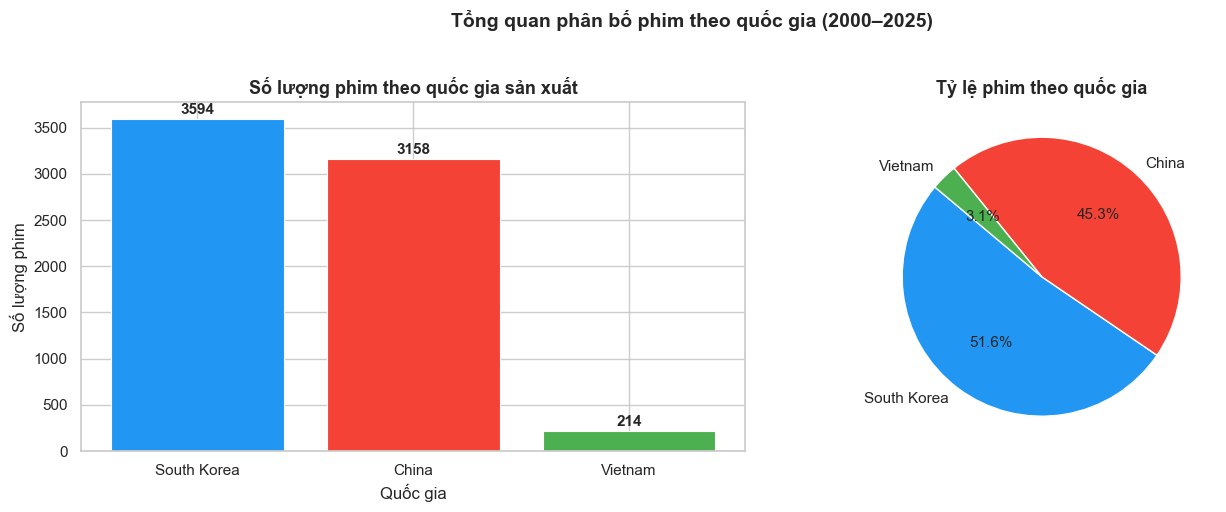

In [3]:
# Thong ke so luong phim theo quoc gia chinh (primary)
print("Phan bo so luong phim theo quoc gia chinh:")
qg_counts = df_clean["QuocGiaChinh"].value_counts()
print(qg_counts)
print("\nTy le phim theo quoc gia chinh:")
print(df_clean["QuocGiaChinh"].value_counts(normalize=True).round(4))

# Thong ke so phim theo nam
print("\nSo luong phim theo nam phat hanh:")
year_counts = df_clean["NamPhatHanh"].value_counts().sort_index()
print(year_counts)

# Bieu do 1: Bar + Pie theo quoc gia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_qg = ["#2196F3", "#F44336", "#4CAF50"]

axes[0].bar(qg_counts.index, qg_counts.values, color=colors_qg, edgecolor="white", linewidth=0.8)
axes[0].set_title("Số lượng phim theo quốc gia sản xuất", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Quốc gia")
axes[0].set_ylabel("Số lượng phim")
for bar, val in zip(axes[0].patches, qg_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(val),
                 ha="center", va="bottom", fontweight="bold", fontsize=11)

axes[1].pie(qg_counts.values, labels=qg_counts.index, autopct="%1.1f%%",
            colors=colors_qg, startangle=140, textprops={"fontsize": 11})
axes[1].set_title("Tỷ lệ phim theo quốc gia", fontsize=13, fontweight="bold")

plt.suptitle("Tổng quan phân bố phim theo quốc gia (2000–2025)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("bieu_do_01_phan_bo_quoc_gia.png", dpi=120, bbox_inches="tight")
plt.show()


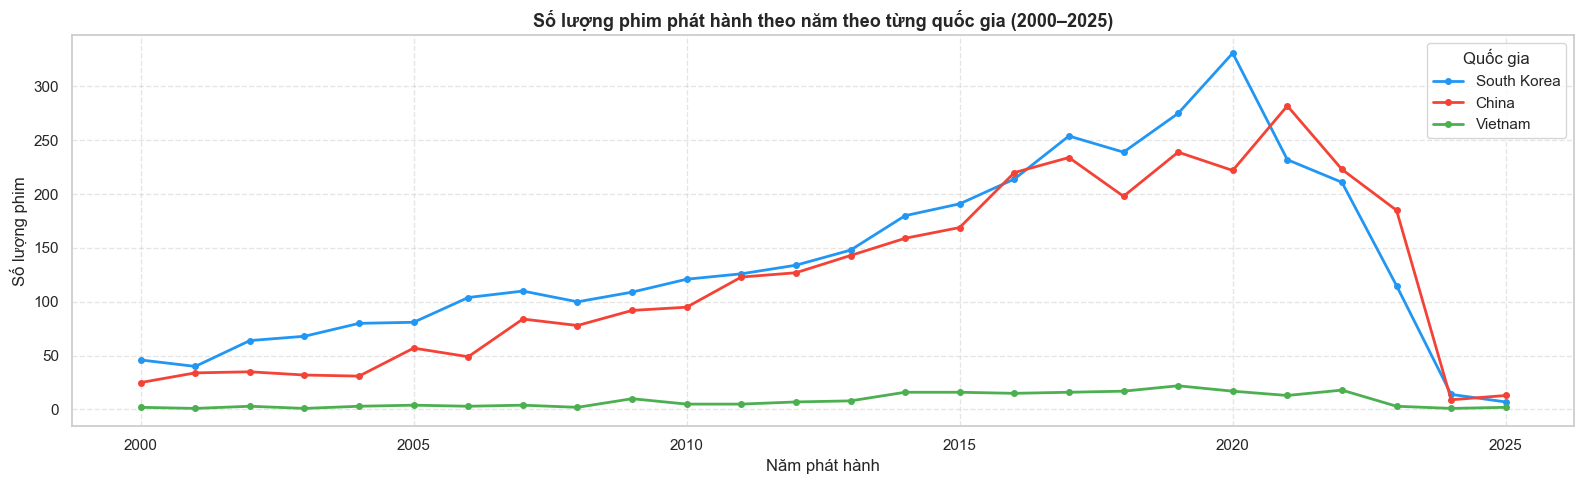

In [4]:

# Bieu do 2: Line chart theo nam
fig, ax = plt.subplots(figsize=(16, 5))
palette = {"South Korea": "#2196F3", "China": "#F44336", "Vietnam": "#4CAF50"}
for qg, color in palette.items():
    sub = df_clean[df_clean["QuocGiaChinh"] == qg].groupby("NamPhatHanh").size()
    ax.plot(sub.index, sub.values, marker="o", markersize=4, label=qg, color=color, linewidth=2)

ax.set_title("Số lượng phim phát hành theo năm theo từng quốc gia (2000–2025)", fontsize=13, fontweight="bold")
ax.set_xlabel("Năm phát hành")
ax.set_ylabel("Số lượng phim")
ax.legend(title="Quốc gia")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("bieu_do_02_phim_theo_nam.png", dpi=120, bbox_inches="tight")
plt.show()

### Nhận xét — Tổng quan phạm vi dữ liệu

- **Hàn Quốc** chiếm tỷ lệ lớn nhất với **3.594 phim (~51.6%)**, tiếp theo là **Trung Quốc** với **3.158 phim (~45.3%)**. **Việt Nam** chỉ có **214 phim (~3.1%)** — phản ánh đúng thực tế quy mô ngành điện ảnh.
- Số lượng phim tăng mạnh từ **2010 đến 2019**, đạt đỉnh vào khoảng **2018–2019**. Sau đó giảm rõ rệt từ **2020** do ảnh hưởng của đại dịch COVID-19 khiến nhiều dự án phim bị hoãn hoặc hủy.
- Giai đoạn **2025** có rất ít phim do dữ liệu chưa đầy đủ (năm chưa kết thúc tại thời điểm thu thập).

## 4. Khám phá thể loại và đặc điểm phim

Kiểm tra phân bố thể loại của phim, tìm ra top 10 thể loại phổ biến nhất và khảo sát xem có sự khác biệt rõ nét nào về thể loại đặc trưng (gu phim) giữa Việt Nam, Hàn Quốc và Trung Quốc hay không.

Top 10 the loai phim pho bien nhat:
TenTheLoai
Drama          3288
Romance        1497
Comedy         1368
Action         1283
Thriller        809
Documentary     609
Crime           539
Fantasy         534
Adventure       482
Mystery         439
Name: count, dtype: int64


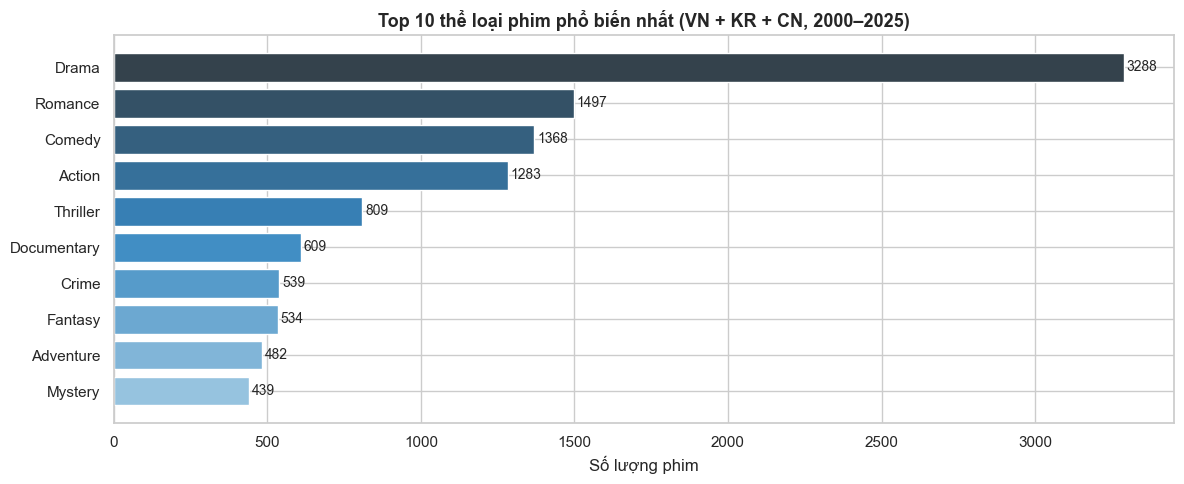

In [5]:
# Ket noi cac bang de nghien cuu the loai phim
df_the_loai = bridge_tl.merge(dim_tl, on="MaTheLoai")
df_phim_tl = df_the_loai.merge(dim_phim, on="MaPhim")

# Top 10 the loai pho bien nhat
print("Top 10 the loai phim pho bien nhat:")
tl_counts = df_the_loai["TenTheLoai"].value_counts()
print(tl_counts.head(10))

# Bieu do 3: Horizontal bar top 10
fig, ax = plt.subplots(figsize=(12, 5))
top10 = tl_counts.head(10)
bars = ax.barh(top10.index[::-1], top10.values[::-1],
               color=sns.color_palette("Blues_d", 10), edgecolor="white")
ax.set_title("Top 10 thể loại phim phổ biến nhất (VN + KR + CN, 2000–2025)", fontsize=13, fontweight="bold")
ax.set_xlabel("Số lượng phim")
for bar, val in zip(bars, top10.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, str(val), va="center", fontsize=10)
plt.tight_layout()
plt.savefig("bieu_do_03_top10_the_loai.png", dpi=120, bbox_inches="tight")
plt.show()


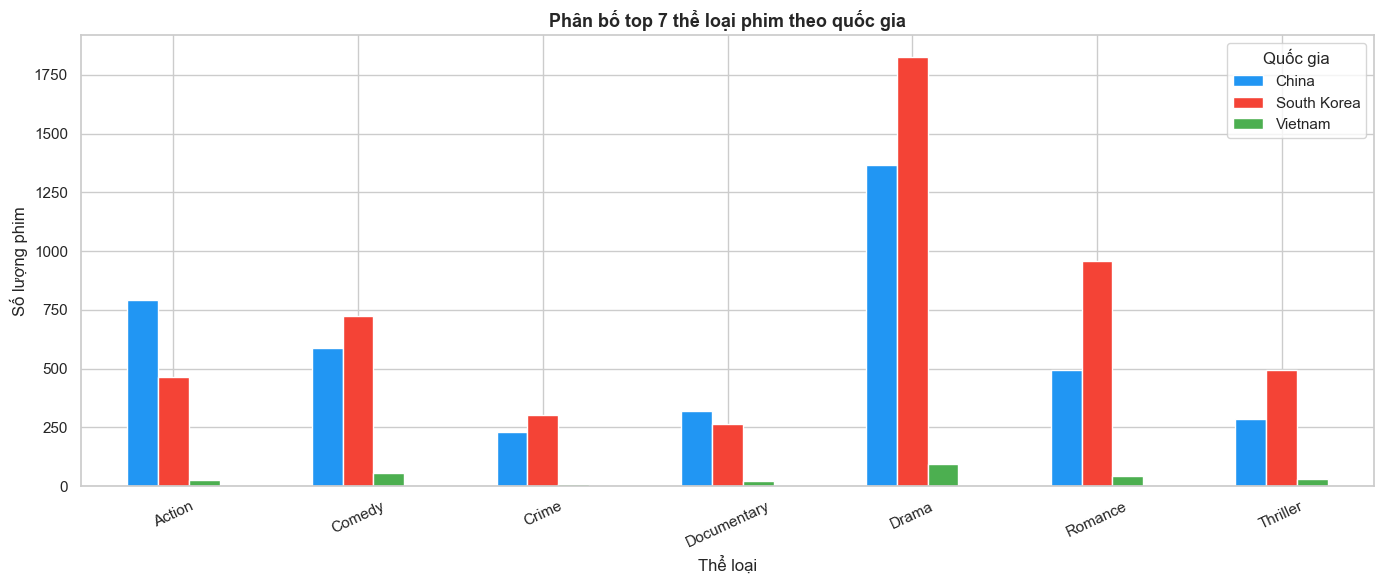

In [6]:

# Bieu do 4: Grouped bar theo quoc gia
df_phim_tl2 = df_the_loai.merge(df_clean[["MaPhim", "QuocGiaChinh"]], on="MaPhim")
top7_genres = tl_counts.head(7).index.tolist()
df_top7 = df_phim_tl2[df_phim_tl2["TenTheLoai"].isin(top7_genres)]
pivot = df_top7.groupby(["QuocGiaChinh", "TenTheLoai"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
pivot.T.plot(kind="bar", ax=ax, color=["#2196F3", "#F44336", "#4CAF50"], edgecolor="white")
ax.set_title("Phân bố top 7 thể loại phim theo quốc gia", fontsize=13, fontweight="bold")
ax.set_xlabel("Thể loại")
ax.set_ylabel("Số lượng phim")
ax.legend(title="Quốc gia")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig("bieu_do_04_the_loai_theo_quoc_gia.png", dpi=120, bbox_inches="tight")
plt.show()

### Nhận xét về thể loại và đặc điểm phim

- **Drama** là thể loại chiếm ưu thế tuyệt đối ở cả 3 quốc gia với **3.288 phim**, gần gấp đôi thể loại đứng thứ 2.
- **Hàn Quốc** nổi bật với **Romance** và **Thriller** — phản ánh đặc trưng của dòng phim K-drama và phim tâm lý hình sự rất thịnh hành.
- **Trung Quốc** có tỷ lệ **Action** và **Adventure** cao hơn so với 2 quốc gia còn lại, tương ứng với xu hướng phim bom tấn thương mại.
- **Việt Nam** có số lượng nhỏ nhưng có xu hướng rõ về **Comedy** và **Drama** trong những năm gần đây.

## 5. Tổng quan các chỉ số đánh giá và chất lượng dữ liệu

Phân tích thống kê mô tả cho các cột chỉ số chính (Điểm đánh giá, Số lượt đánh giá, Độ phổ biến, Thời lượng, Doanh thu, Ngân sách) và phân bố của các cờ chất lượng dữ liệu.

Thong ke mo ta cho cac chi so dinh luong:


,DiemDanhGiaTB,SoLuotDanhGia,DoPhoBien,ThoiLuong,DoanhThu,NganSach
count,6966.00,6966.00,6966.00,6373.00,7.050000e+02,5.440000e+02
mean,6.11,77.58,5.02,98.44,6.177810e+07,2.302604e+07
std,1.77,568.01,21.98,214.78,1.277878e+08,3.879056e+07
min,0.50,1.00,0.00,1.00,3.000000e+00,1.000000e+00
25%,5.00,1.00,0.76,83.00,2.000000e+06,1.083325e+06
50%,6.16,3.00,1.76,97.00,1.190380e+07,8.900000e+06
75%,7.00,14.00,4.58,110.00,6.132194e+07,2.815000e+07
max,10.00,16430.00,1567.27,14400.00,1.000000e+09,4.175490e+08



Phan bo so luong phim theo cac co chat luong:

Co DuSoLuotDanhGia: {False: 4802, True: 2164}

Co CoDoanhThu: {False: 6247, True: 719}

Co CoNganSach: {False: 6416, True: 550}

Co CoThoiLuong: {True: 6475, False: 491}

Co ThoiLuongBatThuong: {False: 6948, True: 18}

Co CanBoSungTenTiengAnh: {False: 6779, True: 187}


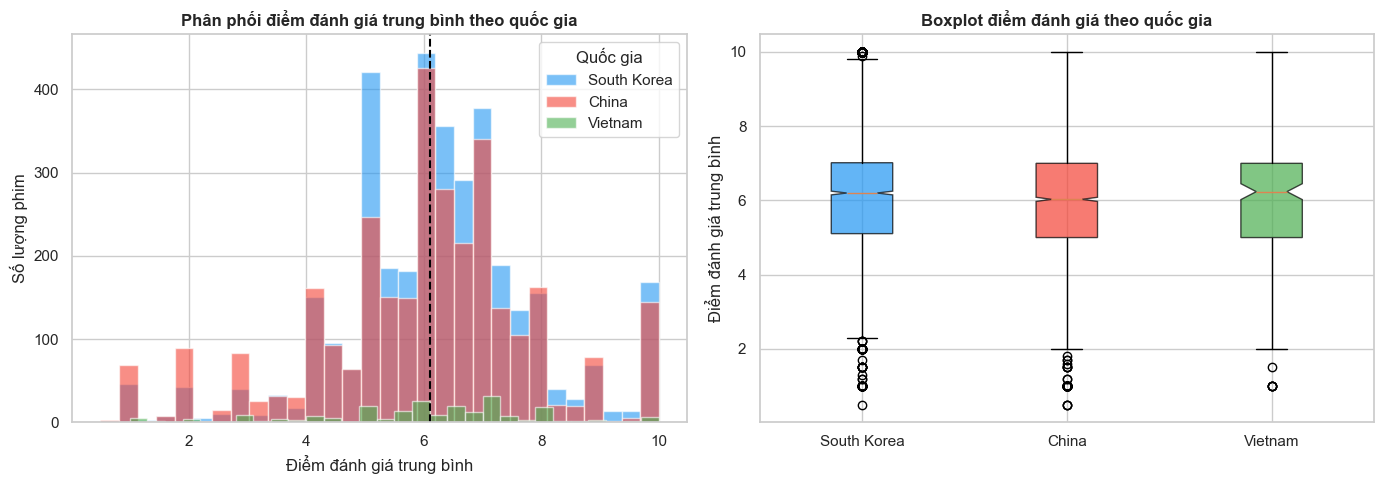

In [7]:
# Thong ke mo ta cac chi so dinh luong
df_clean.columns = df_clean.columns.str.strip()
fact_hs.columns = fact_hs.columns.str.strip()

fact_hs_eda = fact_hs.merge(
    df_clean[["MaPhim", "QuocGiaChinh"]].drop_duplicates("MaPhim"),
    on="MaPhim",
    how="left"
)


cols_dinh_luong = ["DiemDanhGiaTB", "SoLuotDanhGia", "DoPhoBien", "ThoiLuong", "DoanhThu", "NganSach"]
print("Thong ke mo ta cho cac chi so dinh luong:")
display(fact_hs[cols_dinh_luong].describe().round(2))

# Phan bo theo cac co chat luong du lieu
flags = ["DuSoLuotDanhGia", "CoDoanhThu", "CoNganSach", "CoThoiLuong", "ThoiLuongBatThuong", "CanBoSungTenTiengAnh"]
print("\nPhan bo so luong phim theo cac co chat luong:")
for flag in flags:
    if flag in fact_hs.columns:
        print(f"\nCo {flag}:", fact_hs[flag].value_counts().to_dict())
    elif flag in dim_phim.columns:
        print(f"\nCo {flag}:", dim_phim[flag].value_counts().to_dict())

# --- Bieu do 5: Phan phoi diem danh gia ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette_qg = {"South Korea": "#2196F3", "China": "#F44336", "Vietnam": "#4CAF50"}

# Histogram phan phoi diem
for qg, color in palette_qg.items():
    sub = fact_hs_eda[fact_hs_eda["QuocGiaChinh"] == qg]["DiemDanhGiaTB"]
    axes[0].hist(sub, bins=30, alpha=0.6, color=color, label=qg, edgecolor="white")
axes[0].set_title("Phân phối điểm đánh giá trung bình theo quốc gia", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Điểm đánh giá trung bình")
axes[0].set_ylabel("Số lượng phim")
axes[0].legend(title="Quốc gia")
axes[0].axvline(fact_hs["DiemDanhGiaTB"].mean(), color="black", linestyle="--", label=f"Mean = {fact_hs['DiemDanhGiaTB'].mean():.2f}")

# Boxplot theo quoc gia
data_box = [fact_hs_eda[fact_hs_eda["QuocGiaChinh"] == qg]["DiemDanhGiaTB"].dropna() for qg in ["South Korea", "China", "Vietnam"]]
bp = axes[1].boxplot(data_box, tick_labels=["South Korea", "China", "Vietnam"],
                     patch_artist=True, notch=True)
for patch, color in zip(bp["boxes"], ["#2196F3", "#F44336", "#4CAF50"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("Boxplot điểm đánh giá theo quốc gia", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Điểm đánh giá trung bình")

plt.tight_layout()
plt.savefig("bieu_do_05_phan_phoi_diem.png", dpi=120, bbox_inches="tight")
plt.show()


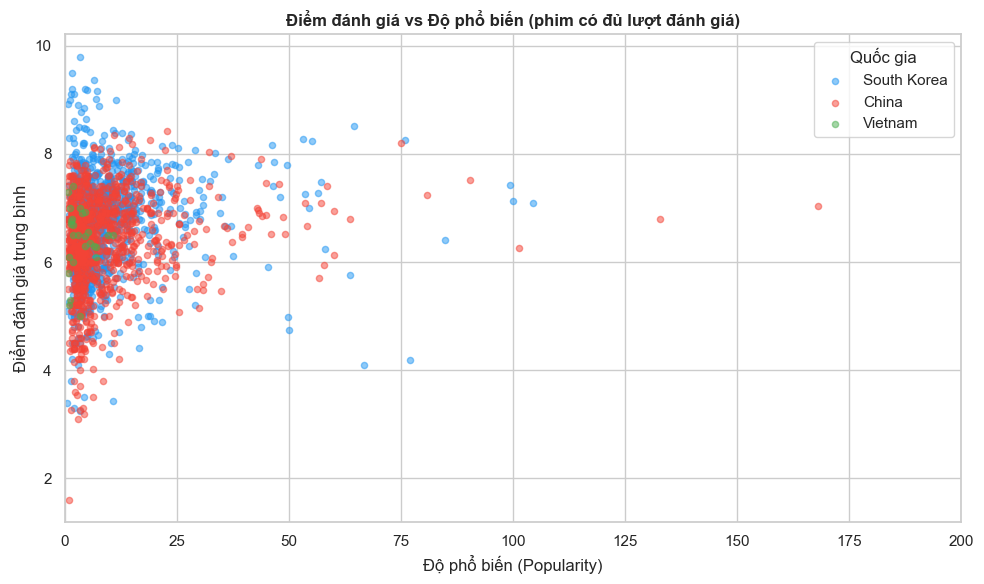

In [8]:
# --- Bieu do 6: Scatter diem vs do pho bien (phim du lieu luot danh gia) ---
df_plot = fact_hs_eda[fact_hs_eda["DuSoLuotDanhGia"] == True].copy()
fig, ax = plt.subplots(figsize=(10, 6))
for qg, color in palette_qg.items():
    sub = df_plot[df_plot["QuocGiaChinh"] == qg]
    ax.scatter(sub["DoPhoBien"], sub["DiemDanhGiaTB"], alpha=0.5, s=20, color=color, label=qg)
ax.set_title("Điểm đánh giá vs Độ phổ biến (phim có đủ lượt đánh giá)", fontsize=12, fontweight="bold")
ax.set_xlabel("Độ phổ biến (Popularity)")
ax.set_ylabel("Điểm đánh giá trung bình")
ax.set_xlim(0, 200)
ax.legend(title="Quốc gia")
plt.tight_layout()
plt.savefig("bieu_do_06_scatter_diem_pho_bien.png", dpi=120, bbox_inches="tight")
plt.show()

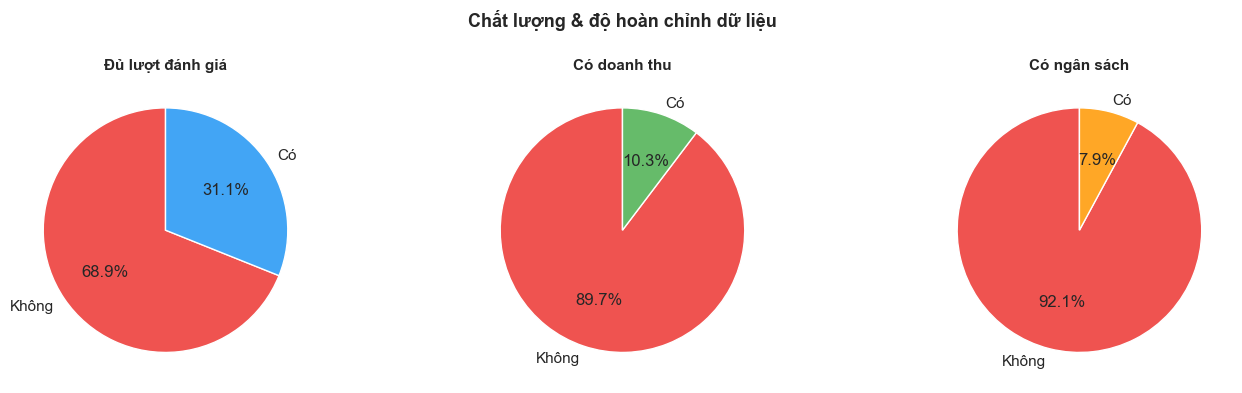

In [9]:
# --- Bieu do 7: Chat luong du lieu (co doanh thu, ngan sach) ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
flag_info = {
    "DuSoLuotDanhGia": ("Đủ lượt đánh giá", ["#EF5350", "#42A5F5"]),
    "CoDoanhThu":       ("Có doanh thu",      ["#EF5350", "#66BB6A"]),
    "CoNganSach":       ("Có ngân sách",      ["#EF5350", "#FFA726"]),
}
for ax, (flag, (title, colors)) in zip(axes, flag_info.items()):
    col = fact_hs[flag] if flag in fact_hs.columns else dim_phim[flag]
    vals = col.value_counts()
    ax.pie(vals.values, labels=["Không" if k == False else "Có" for k in vals.index],
           autopct="%1.1f%%", colors=colors, startangle=90)
    ax.set_title(title, fontsize=11, fontweight="bold")
plt.suptitle("Chất lượng & độ hoàn chỉnh dữ liệu", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("bieu_do_07_chat_luong_du_lieu.png", dpi=120, bbox_inches="tight")
plt.show()

### Nhận xét — Chỉ số đánh giá và chất lượng dữ liệu

**Phân bố điểm đánh giá:**
- Điểm đánh giá trung bình toàn dataset là **~6.1/10**, phân phối có dạng lệch phải nhẹ — tập trung nhiều ở vùng **5.0–7.5**.
- **Hàn Quốc** có điểm trung bình cao nhất (~6.3), tiếp theo **Trung Quốc** (~6.1), thấp nhất là **Việt Nam** (~5.8). Khoảng cách không quá lớn nhưng phản ánh mức độ được đánh giá trên nền tảng quốc tế (TMDB).
- Boxplot cho thấy cả 3 quốc gia đều có nhiều outlier điểm thấp (<3.0) — thường là phim ít được biết đến, rất ít lượt đánh giá.

**Tương quan điểm vs độ phổ biến:**
- **Không có tương quan tuyến tính rõ ràng** giữa độ phổ biến và điểm đánh giá. Phim phổ biến cao chưa chắc có điểm cao — "viral" không đồng nghĩa với "chất lượng".

**Chất lượng dữ liệu:**
- Chỉ **~31%** phim đủ lượt đánh giá → cần lọc cột `DuSoLuotDanhGia = True` trước khi phân tích xu hướng chất lượng.
- **Doanh thu (~10%)** và **ngân sách (~8%)** bị thiếu rất nhiều → hạn chế phân tích tài chính, nên kết hợp file `enriched`.
- Chỉ **18 phim** có thời lượng bất thường — không ảnh hưởng đáng kể đến tổng thể.

## Kết luận EDA sơ bộ

Qua quá trình khám phá dữ liệu (EDA), nhóm rút ra các điểm chính sau:

1. **Quy mô dữ liệu:** Dataset gồm **6.966 phim** từ Việt Nam, Hàn Quốc, Trung Quốc trong giai đoạn 2000–2025, được tổ chức theo mô hình Star Schema với 5 bảng Dim, 1 bảng Fact và 2 bảng Bridge.

2. **Mất cân bằng dữ liệu theo quốc gia:** Hàn Quốc (51.6%) và Trung Quốc (45.3%) chiếm đa số, Việt Nam chỉ chiếm 3.1% — cần chú ý khi so sánh số lượng tuyệt đối giữa các quốc gia.

3. **Xu hướng phát hành:** Số lượng phim tăng mạnh giai đoạn 2010–2019, đạt đỉnh khoảng 2018–2019, sau đó giảm nhẹ do ảnh hưởng của đại dịch COVID-19.

4. **Thể loại đặc trưng:** Drama là thể loại chủ đạo ở cả 3 quốc gia. Hàn Quốc nổi bật với Romance, Hàn và Trung Quốc thiên về Action, Việt Nam dần phát triển Comedy và Thriller.

5. **Chất lượng dữ liệu:** Các trường định lượng quan trọng (doanh thu, ngân sách) còn thiếu nhiều, cần sử dụng dữ liệu bổ sung từ file `enriched`. Điểm đánh giá và thể loại là hai chiều dữ liệu đầy đủ và đáng tin cậy nhất cho phân tích.

**Hướng phân tích của nhóm:**
- Phân tích xu hướng sản xuất phim của Việt Nam, Hàn Quốc và Trung Quốc trong giai đoạn 2000–2025
- Phân tích cơ cấu thể loại phim và đặc điểm nội dung nổi bật của từng quốc gia.
- Phân tích mức độ đánh giá và sự quan tâm của khán giả đối với phim của từng quốc gia.
- Khám phá các phim nổi bật và các yếu tố giúp phim thu hút sự chú ý của khán giả.